<a href="https://colab.research.google.com/github/Max48732/-/blob/main/CodeLab3_SparkData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Технологии обработки больших данных

Занятие 3. PySpark Data Structures

0. Запуск PySpark на локальной машине
1. Spark DataFrame
2. Spark RDD (разбор предыдущего ДЗ)
3. Spark Pandas API DataFrame
4. Домашнее задание

In [1]:
%%bash
pip install pandas pyarrow plotly

In [2]:
! pip install pyspark

In [3]:
import pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

Рассмотрим пример данных [German Credit](https://www.kaggle.com/uciml/german-credit), которые используются для решении задачи кредитного скоринга. Это небольшой датасет с информацией о клиентах, необходимой для принятия решения - выдавать кредит или нет.  

Сегодня мы не будем решать задачу предсказания, просто разберемся с основными приемами EDA (Exploratory data analysis, [Разведочный анализ данных](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85)).

In [11]:
DATA_PATH = 'credit_data.csv'

**Columns**  

Age (numeric)  
Sex (text: male, female)  
Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)  
Housing (text: own, rent, or free)  
Saving accounts (text - little, moderate, quite rich, rich)  
Checking account (numeric, in DM - Deutsch Mark)  
Credit amount (numeric, in DM)  
Duration (numeric, in month)  
Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)

## 1. Spark DataFrame

Базовый класс для работы со структуированными данными в pyspark.

In [9]:
from google.colab import files

uploaded = files.upload()

import os
print("Файлы после загрузки:", os.listdir('.'))

df = spark.read.csv('credit_data.csv', header=True)
df.show(5)

Saving credit_data.csv to credit_data (1).csv
Файлы после загрузки: ['.config', 'credit_data (1).csv', 'credit_data.csv', 'sample_data']
+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
| id|Age|   Sex|Job|Housing|Saving_accounts|Checking_account|Credit_amount|Duration|            Purpose|
+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
|  0| 67|  male|  2|    own|             NA|          little|         1169|       6|           radio/TV|
|  1| 22|female|  2|    own|         little|        moderate|         5951|      48|           radio/TV|
|  2| 49|  male|  1|    own|         little|              NA|         2096|      12|          education|
|  3| 45|  male|  2|   free|         little|          little|         7882|      42|furniture/equipment|
|  4| 53|  male|  2|   free|         little|          little|         4870|      24|                car|
+---+---+------+---+---

In [12]:
df = spark.read.csv(DATA_PATH, header=True)
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [13]:
# First rows in this DataFrame
df.show(10, truncate=False)

+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
|id |Age|Sex   |Job|Housing|Saving_accounts|Checking_account|Credit_amount|Duration|Purpose            |
+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
|0  |67 |male  |2  |own    |NA             |little          |1169         |6       |radio/TV           |
|1  |22 |female|2  |own    |little         |moderate        |5951         |48      |radio/TV           |
|2  |49 |male  |1  |own    |little         |NA              |2096         |12      |education          |
|3  |45 |male  |2  |free   |little         |little          |7882         |42      |furniture/equipment|
|4  |53 |male  |2  |free   |little         |little          |4870         |24      |car                |
|5  |35 |male  |1  |free   |NA             |NA              |9055         |36      |education          |
|6  |53 |male  |2  |own    |quite rich     |NA         

### Схема данных как в SQL

In [14]:
schema = "id INT, Age INT, Sex STRING, Job INT, Housing STRING, Saving_accounts STRING, \
Checking_account STRING, Credit_amount INT, Duration INT, Purpose STRING"

In [16]:
df = spark.read.csv('credit_data.csv', schema=schema, header=True )

In [17]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Job: integer (nullable = true)
 |-- Housing: string (nullable = true)
 |-- Saving_accounts: string (nullable = true)
 |-- Checking_account: string (nullable = true)
 |-- Credit_amount: integer (nullable = true)
 |-- Duration: integer (nullable = true)
 |-- Purpose: string (nullable = true)



### Сортировка и фильтрация данных

In [18]:
# One column sorting
df.sort('Job', ascending=False).show()

+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
| id|Age|   Sex|Job|Housing|Saving_accounts|Checking_account|Credit_amount|Duration|            Purpose|
+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+
| 56| 52|  male|  3|    own|             NA|        moderate|         6468|      12|           radio/TV|
|175| 53|female|  3|    own|             NA|              NA|         7485|      30|                car|
| 58| 23|female|  3|    own|         little|            rich|         1961|      18|                car|
|  9| 28|  male|  3|    own|         little|        moderate|         5234|      30|                car|
| 62| 61|  male|  3|   free|         little|        moderate|         1953|      36|           business|
| 51| 30|  male|  3|    own|         little|        moderate|         5965|      27|                car|
| 72| 51|  male|  3|   free|         little|          l

In [19]:
# Few columns sorting
df.sort(['Age', 'Credit_amount'], ascending=[False, True]).show()

+---+---+------+---+-------+---------------+----------------+-------------+--------+---------+
| id|Age|   Sex|Job|Housing|Saving_accounts|Checking_account|Credit_amount|Duration|  Purpose|
+---+---+------+---+-------+---------------+----------------+-------------+--------+---------+
|536| 75|female|  3|    own|             NA|          little|         1374|       6|      car|
|330| 75|  male|  3|   free|         little|          little|         6615|      24|      car|
|756| 74|  male|  0|    own|         little|            rich|         1299|       6|      car|
|430| 74|  male|  1|    own|         little|              NA|         3448|       5| business|
|606| 74|  male|  3|    own|         little|              NA|         4526|      24| business|
|186| 74|female|  3|   free|         little|        moderate|         5129|       9|      car|
|163| 70|  male|  3|   free|         little|        moderate|         7308|      10|      car|
|187| 68|  male|  0|   free|         little|      

In [20]:
df_car = df.filter(df["Purpose"] == 'car')

In [21]:
# Доля автокредитов
df_car.count() / df.count()

0.337

### Группировка данных

In [22]:
df.groupBy("Age").count().sort('Age').show()

+---+-----+
|Age|count|
+---+-----+
| 19|    2|
| 20|   14|
| 21|   14|
| 22|   27|
| 23|   48|
| 24|   44|
| 25|   41|
| 26|   50|
| 27|   51|
| 28|   43|
| 29|   37|
| 30|   40|
| 31|   38|
| 32|   34|
| 33|   33|
| 34|   32|
| 35|   40|
| 36|   39|
| 37|   29|
| 38|   24|
+---+-----+
only showing top 20 rows


## 2. Spark RDD

Resilient Distributed Dataset.
Менее удобный, но более производительный контейнер для данных.  

Подробнее про DataFrame, DataSet и RDD на русском языке
[1](https://www.bigdataschool.ru/blog/spark-sql-data-structures.html),
[2](https://www.bigdataschool.ru/blog/rdd-vs-dataframe-vs-dataset.html).  

На английском рекомендую [официальный гайд](https://spark.apache.org/docs/latest/sql-getting-started.html).

In [25]:
log_content = """2024-01-01 10:00:00 INFO Application started
2024-01-01 10:05:23 WARNING Memory usage high
2024-01-01 10:10:15 ERROR Connection timeout
2024-01-01 10:15:42 INFO Processing completed
2024-01-01 10:20:08 ERROR Database connection failed
2024-01-01 10:25:30 INFO Retry attempt 1
2024-01-01 10:30:45 WARNING Slow response time
2024-01-01 10:35:12 ERROR Authentication failed
2024-01-01 10:40:33 INFO User logged out"""

with open('log.txt', 'w') as f:
    f.write(log_content)

print("Файл log.txt успешно создан в папке sample_data!")

log_file = spark.read.text('log.txt')
log_file.show(10)

Файл log.txt успешно создан в папке sample_data!
+--------------------+
|               value|
+--------------------+
|2024-01-01 10:00:...|
|2024-01-01 10:05:...|
|2024-01-01 10:10:...|
|2024-01-01 10:15:...|
|2024-01-01 10:20:...|
|2024-01-01 10:25:...|
|2024-01-01 10:30:...|
|2024-01-01 10:35:...|
|2024-01-01 10:40:...|
+--------------------+



In [27]:
log_file = spark.read.text('log.txt')

In [28]:
%%time

# Note, we cant use   lambda x:   x.value.upper()
df = log_file.rdd.map(lambda x: ( x.value.upper() ,) ).toDF()

df.show(truncate=False)

+----------------------------------------------------+
|_1                                                  |
+----------------------------------------------------+
|2024-01-01 10:00:00 INFO APPLICATION STARTED        |
|2024-01-01 10:05:23 WARNING MEMORY USAGE HIGH       |
|2024-01-01 10:10:15 ERROR CONNECTION TIMEOUT        |
|2024-01-01 10:15:42 INFO PROCESSING COMPLETED       |
|2024-01-01 10:20:08 ERROR DATABASE CONNECTION FAILED|
|2024-01-01 10:25:30 INFO RETRY ATTEMPT 1            |
|2024-01-01 10:30:45 WARNING SLOW RESPONSE TIME      |
|2024-01-01 10:35:12 ERROR AUTHENTICATION FAILED     |
|2024-01-01 10:40:33 INFO USER LOGGED OUT            |
+----------------------------------------------------+

CPU times: user 19.2 ms, sys: 2.01 ms, total: 21.2 ms
Wall time: 2.1 s


In [31]:
white_list_content = """apple
banana
cherry
date
elderberry
fig
grape"""

with open('white_list.txt', 'w') as f:
    f.write(white_list_content)

print("Файл white_list.txt создан!")

with open('white_list.txt') as f:
    ww = f.readlines()

ww = "".join([w for w in ww]).split()
ww = list(map(str.lower, ww))
print("White list:", ww)

Файл white_list.txt создан!
White list: ['apple', 'banana', 'cherry', 'date', 'elderberry', 'fig', 'grape']


In [33]:
with open('white_list.txt') as f:
    ww = f.readlines()

ww = "".join([w for w in ww]).split()
ww = list(map(str.lower, ww))

In [34]:
def white_filter(s):
    w = s.value.split()
    timestamp = str(w[0]) + str(w[1]) + " "
    words = w[2:]
    filtered_words = list(filter(lambda x: x in ww, words))
    return (timestamp, " ".join([w for w in filtered_words])  )

In [35]:
%%time
df2 = log_file.rdd.map(white_filter).toDF(schema=('TimeStamp', 'Words'))
df2.show(truncate=False)

+-------------------+-----+
|TimeStamp          |Words|
+-------------------+-----+
|2024-01-0110:00:00 |     |
|2024-01-0110:05:23 |     |
|2024-01-0110:10:15 |     |
|2024-01-0110:15:42 |     |
|2024-01-0110:20:08 |     |
|2024-01-0110:25:30 |     |
|2024-01-0110:30:45 |     |
|2024-01-0110:35:12 |     |
|2024-01-0110:40:33 |     |
+-------------------+-----+

CPU times: user 13.6 ms, sys: 3.77 ms, total: 17.4 ms
Wall time: 1.36 s


In [36]:
wordCounts = df2.rdd.flatMap(lambda line: line[1].split(" "))\
                      .map(lambda word: (word, 1))\
                      .reduceByKey(lambda a, b: a + b)

In [37]:
%%time
wordCounts.toDF().show()

+---+---+
| _1| _2|
+---+---+
|   |  9|
+---+---+

CPU times: user 12.8 ms, sys: 2.91 ms, total: 15.7 ms
Wall time: 1.46 s


## 3. Spark Pandas API

Начиная с версии Spark 3.2 имеется реализация Pandas API.    
Хороший материал непосредственно по pandas: [mlcourse.ai](https://habr.com/ru/company/ods/blog/322626/)

In [38]:
# import pandas as pd

import pyspark.pandas as pd

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [43]:
df = pd.read_csv('credit_data.csv')
type(df)

pandas.core.frame.DataFrame

In [44]:
df.head()

,id,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving_accounts   817 non-null    object
 6   Checking_account  606 non-null    object
 7   Credit_amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [47]:
# Средний возраст заемщиков
df['Age'].mean()

np.float64(35.546)

In [48]:
# Статистика по всем числовым колонкам
df.describe()

,id,Age,Job,Credit_amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


### Индексация и фильтрация данных

In [49]:
# Индексация python slices
df[1:11:2]

,id,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
5,5,35,male,1,free,NaN,NaN,9055,36,education
7,7,35,male,3,rent,little,moderate,6948,36,car
9,9,28,male,3,own,little,moderate,5234,30,car


In [50]:
# Фильтрация по условию
df[df["Sex"] == 'male']

,id,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
5,5,35,male,1,free,NaN,NaN,9055,36,education
...,...,...,...,...,...,...,...,...,...,...
994,994,50,male,2,own,NaN,NaN,2390,12,car
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [51]:
# Какой средний размер кредита у заемщиков мужчин?
df[df["Sex"] == 'male']['Credit_amount'].mean()

np.float64(3448.040579710145)

In [52]:
# Какой средний размер кредита у заемщиков женщин?
df[df["Sex"] == 'female']['Credit_amount'].mean()

np.float64(2877.7741935483873)

### Группировка данных

In [53]:
# Группировка разделяет df на несколько частей, в которых значения заданной колонки будут одинаковыми
df.groupby('Sex')

In [54]:
# Можно указать какие колонки нас интересуют
df.groupby('Sex')['Credit_amount']

In [55]:
# В конце группировки нужно указать функцию
df.groupby('Sex')['Credit_amount'].mean()

,Credit_amount
Sex,
female,2877.774194
male,3448.040580


### Визуализация

<Axes: >

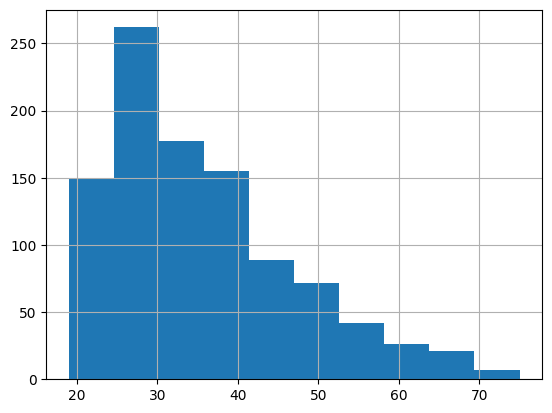

In [56]:
df['Age'].hist()

<Axes: >

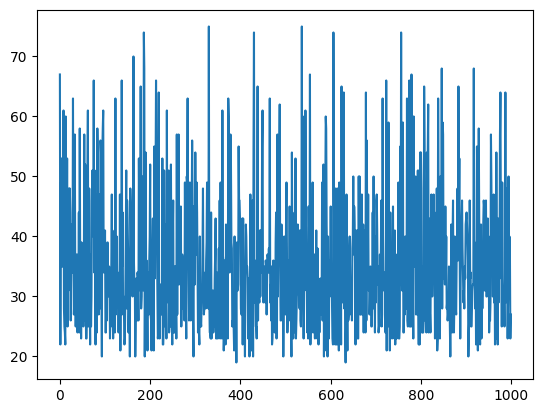

In [57]:
df['Age'].plot()

## 4. Домашнее задание  



1. Сколько мужчин и женщин (признак Sex) представлено в этом наборе данных?

In [59]:
sex_counts = df['Sex'].value_counts()
print(" Количество мужчин и женщин:")
print(sex_counts)

 Количество мужчин и женщин:
Sex
male      690
female    310
Name: count, dtype: int64


2. Каков средний возраст (признак Age) женщин?

In [60]:
avg_age_female = df[df['Sex'] == 'female']['Age'].mean()
print(f" Средний возраст женщин: {avg_age_female:.1f} лет")

avg_age_male = df[df['Sex'] == 'male']['Age'].mean()
print(f" Средний возраст мужчин: {avg_age_male:.1f} лет")

 Средний возраст женщин: 32.8 лет
 Средний возраст мужчин: 36.8 лет


3. Какова доля заемщиков с собственным жильем (признак Housing)?

In [61]:
own_housing = df[df['Housing'] == 'own'].shape[0]
total = df.shape[0]
ratio = own_housing / total * 100

print(f" Заемщиков с собственным жильем: {own_housing} из {total}")
print(f" Доля: {ratio:.1f}%")

print("\n Распределение по типам жилья:")
housing_counts = df['Housing'].value_counts()
print(housing_counts)

 Заемщиков с собственным жильем: 713 из 1000
 Доля: 71.3%

 Распределение по типам жилья:
Housing
own     713
rent    179
free    108
Name: count, dtype: int64


4. Каково среднее значение возраста тех, кто имеет высокие накопления (признак Saving_accounts)?

In [62]:
high_savings = df[df['Saving_accounts'].isin(['rich', 'quite rich'])]
avg_age_high = high_savings['Age'].mean()

print(f" Заемщиков с высокими накоплениями: {high_savings.shape[0]}")
print(f" Средний возраст: {avg_age_high:.1f} лет")

 Заемщиков с высокими накоплениями: 111
 Средний возраст: 37.0 лет


5. Каково среднеквадратичное отклонения возраста тех, кто имеет высокие накопления (признак Saving_accounts)?

In [63]:
std_age_high = high_savings['Age'].std()

print(f" Среднеквадратичное отклонение возраста: {std_age_high:.2f}")
print(f" Средний возраст ± отклонение: {avg_age_high:.1f} ± {std_age_high:.1f} лет")

 Среднеквадратичное отклонение возраста: 11.73
 Средний возраст ± отклонение: 37.0 ± 11.7 лет


6. Выведите гистограмму категорий покупок (признак Purpose) для мужчин и женщин.

In [64]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

male_purposes = df[df['Sex'] == 'male']['Purpose'].value_counts()
female_purposes = df[df['Sex'] == 'female']['Purpose'].value_counts()

male_labels = male_purposes.index.to_list()
male_values = male_purposes.to_list()

female_labels = female_purposes.index.to_list()
female_values = female_purposes.to_list()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Цели кредитов - Мужчины', 'Цели кредитов - Женщины')
)

fig.add_trace(
    go.Bar(x=male_labels, y=male_values, name='Мужчины', marker_color='steelblue'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=female_labels, y=female_values, name='Женщины', marker_color='coral'),
    row=1, col=2
)

fig.update_layout(
    height=500,
    showlegend=False,
    title_text="Распределение целей кредитов по полу"
)
fig.update_xaxes(tickangle=45)
fig.show()

print(" Топ-3 цели кредитов для мужчин:")
print(male_purposes.head(3))
print("\n Топ-3 цели кредитов для женщин:")
print(female_purposes.head(3))

 Топ-3 цели кредитов для мужчин:
Purpose
car                    243
radio/TV               195
furniture/equipment    107
Name: count, dtype: int64

 Топ-3 цели кредитов для женщин:
Purpose
car                    94
radio/TV               85
furniture/equipment    74
Name: count, dtype: int64


7. На что чаще всего берутся длинные кредиты (более 24 мес)?

In [65]:
long_credits = df[df['Duration'] > 24]

purposes_long = long_credits['Purpose'].value_counts()

print(f" Всего кредитов: {df.shape[0]}")
print(f" Длинных кредитов (>24 мес): {long_credits.shape[0]}")
print(f" Доля длинных кредитов: {long_credits.shape[0] / df.shape[0] * 100:.1f}%")

top_purpose = purposes_long.index.to_list()[0]

print(f"\n Чаще всего длинные кредиты берут на: **{top_purpose}**")
print(f" Количество таких кредитов: {purposes_long.iloc[0]}")
print(f" Доля от всех длинных кредитов: {purposes_long.iloc[0] / long_credits.shape[0] * 100:.1f}%")

print("\nПолное распределение целей для длинных кредитов:")
print(purposes_long)

 Всего кредитов: 1000
 Длинных кредитов (>24 мес): 230
 Доля длинных кредитов: 23.0%

 Чаще всего длинные кредиты берут на: **car**
 Количество таких кредитов: 74
 Доля от всех длинных кредитов: 32.2%

Полное распределение целей для длинных кредитов:
Purpose
car                    74
radio/TV               58
business               41
furniture/equipment    31
education              14
repairs                 5
vacation/others         5
domestic appliances     2
Name: count, dtype: int64


8. Какой средний срок кредита (признак Duration) для заемщиков, имеющих высокие текущие траты (признак Checking_account)?

In [66]:
high_checking = df[df['Checking_account'] == 'rich']

avg_duration_high = high_checking['Duration'].mean()

print(f" Количество заемщиков: {high_checking.shape[0]}")
print(f" Средний срок кредита: {avg_duration_high:.2f} месяцев")

print(f"\n Дополнительная статистика:")
print(f"Минимальный срок: {high_checking['Duration'].min()} мес")
print(f"Максимальный срок: {high_checking['Duration'].max()} мес")
print(f"Медианный срок: {high_checking['Duration'].median():.0f} мес")
print(f"Стандартное отклонение: {high_checking['Duration'].std():.2f}")

 Количество заемщиков: 63
 Средний срок кредита: 17.35 месяцев

 Дополнительная статистика:
Минимальный срок: 4 мес
Максимальный срок: 42 мес
Медианный срок: 15 мес
Стандартное отклонение: 9.52


9. Какой средний срок кредита (признак Duration) для заемщиков, имеющих низкие текущие траты (признак Checking_account)?

In [67]:
low_checking = df[df['Checking_account'] == 'little']

avg_duration_low = low_checking['Duration'].mean()

print(f" Количество заемщиков: {low_checking.shape[0]}")
print(f" Средний срок кредита: {avg_duration_low:.2f} месяцев")

print(f"\n Дополнительная статистика:")
print(f"Минимальный срок: {low_checking['Duration'].min()} мес")
print(f"Максимальный срок: {low_checking['Duration'].max()} мес")
print(f"Медианный срок: {low_checking['Duration'].median():.0f} мес")
print(f"Стандартное отклонение: {low_checking['Duration'].std():.2f}")

 Количество заемщиков: 274
 Средний срок кредита: 21.34 месяцев

 Дополнительная статистика:
Минимальный срок: 6 мес
Максимальный срок: 60 мес
Медианный срок: 18 мес
Стандартное отклонение: 11.66


10. На какую цель взят самый дорогой кредит?

In [68]:
max_credit_idx = df['Credit_amount'].idxmax()
max_credit = df.loc[max_credit_idx]

print(f" Сумма кредита: {max_credit['Credit_amount']} DM")
print(f" Цель кредита: {max_credit['Purpose']}")
print(f" Срок кредита: {max_credit['Duration']} месяцев")
print(f" Возраст заемщика: {max_credit['Age']} лет")
print(f" Пол заемщика: {max_credit['Sex']}")
print(f" Тип жилья: {max_credit['Housing']}")
print(f" Категория работы: {max_credit['Job']}")
print(f" Накопления: {max_credit['Saving_accounts']}")
print(f" Текущие траты: {max_credit['Checking_account']}")

print(f"\n ОТВЕТ: Самый дорогой кредит взят на цель: **{max_credit['Purpose']}**")

 Сумма кредита: 18424 DM
 Цель кредита: vacation/others
 Срок кредита: 48 месяцев
 Возраст заемщика: 32 лет
 Пол заемщика: female
 Тип жилья: own
 Категория работы: 3
 Накопления: little
 Текущие траты: moderate

 ОТВЕТ: Самый дорогой кредит взят на цель: **vacation/others**
